In [1]:
import pandas as pd
import math
from numpy.linalg import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Feature selection
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    RFE
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")

FEATURES = [
    'Birth Rate', 'Fertility Rate', 'Infant Mortality',
    'Life Expectancy', 'GDP', 'Unemployment Rate',
    'Urban Population', 'CO2-Emissions',
    'Physicians per Thousand', 'Density (P/Km2)'
]
# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")
print(f"UMAP available: {UMAP_AVAILABLE}")

Libraries loaded successfully.
UMAP available: True


In [2]:
pd.set_option('display.max_columns', None)
# Load the dataset
df = pd.read_csv("world-data-2023.csv")

# Display the first 5 rows
print("="*75)
print("FIRST 5 ROWS OF THE DATASET".center(80))
print("="*75 + "\n")
print(df.head())

                          FIRST 5 ROWS OF THE DATASET                           

       Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
0  Afghanistan               60           AF                58.10%   
1      Albania              105           AL                43.10%   
2      Algeria               18           DZ                17.40%   
3      Andorra              164           AD                40.00%   
4       Angola               26           AO                47.50%   

  Land Area(Km2) Armed Forces size  Birth Rate  Calling Code  \
0        652,230           323,000       32.49          93.0   
1         28,748             9,000       11.78         355.0   
2      2,381,741           317,000       24.28         213.0   
3            468               NaN        7.20         376.0   
4      1,246,700           117,000       40.73         244.0   

  Capital/Major City Co2-Emissions     CPI CPI Change (%) Currency-Code  \
0              Kabul         8,672   

In [3]:
# Extract the dataset shape
rows_num, cols_num = df.shape

# Display dataset shape (rows and columns)
print("="*25)
print("DATASET SHAPE".center(25))
print("="*25 + "\n")
print(f"Rows: {rows_num}")
print(f"Columns: {cols_num}")

      DATASET SHAPE      

Rows: 195
Columns: 35


In [4]:
df_cleaned = df[['Birth Rate', 'Fertility Rate', 'Infant mortality',
    'Life expectancy', 'GDP', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions',
    'Physicians per thousand', 'Density\n(P/Km2)']]

In [5]:
# Extract the dataset shape
rows_num, cols_num = df_cleaned.shape
# Display dataset shape (rows and columns)
print("="*25)
print("DATASET SHAPE".center(25))
print("="*25 + "\n")
print(f"Rows: {rows_num}")
print(f"Columns: {cols_num}")

      DATASET SHAPE      

Rows: 195
Columns: 10


In [6]:
# Dislay dataset non-null count and datatypes
print("="*55)
print("DATASET INFORMATION".center(55))
print("="*55 + "\n")
df_cleaned.info()

                  DATASET INFORMATION                  

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Birth Rate               189 non-null    float64
 1   Fertility Rate           188 non-null    float64
 2   Infant mortality         189 non-null    float64
 3   Life expectancy          187 non-null    float64
 4   GDP                      193 non-null    str    
 5   Unemployment rate        176 non-null    str    
 6   Urban_population         190 non-null    str    
 7   Co2-Emissions            188 non-null    str    
 8   Physicians per thousand  188 non-null    float64
 9   Density
(P/Km2)          195 non-null    str    
dtypes: float64(5), str(5)
memory usage: 15.4 KB


In [7]:
# Remove rows with NaN values
df_cleaned = df_cleaned.dropna()
# Extract the dataset shape again
rows_num, cols_num = df_cleaned.shape
# Display the dataframe shape again
print("="*25)
print("DATASET SHAPE".center(25))
print("="*25 + "\n")
print(f"Rows: {rows_num}")
print(f"Columns: {cols_num}")

      DATASET SHAPE      

Rows: 175
Columns: 10


* 20 Rows were removed and 10 columns remain as per instruction.
* There are 4 columns that are strings, we must fix the strings in the columns i.e. commas, percents sign and dollar signs

In [8]:
# Define which columns need cleaning
cols_to_fix = ['Unemployment rate', 'Urban_population', 'Co2-Emissions', 'GDP', 'Density\n(P/Km2)']

for col in cols_to_fix:
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace(r'[$,%]', '', regex=True)
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

df_cleaned['Unemployment rate'] = df_cleaned['Unemployment rate'] / 100

In [9]:
df_cleaned.head

<bound method NDFrame.head of      Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
0         32.49            4.47              47.9             64.5   
1         11.78            1.62               7.8             78.5   
2         24.28            3.02              20.1             76.7   
4         40.73            5.52              51.6             60.8   
6         17.02            2.26               8.8             76.5   
..          ...             ...               ...              ...   
190       17.88            2.27              21.4             72.1   
191       16.75            2.05              16.5             75.3   
192       30.45            3.79              42.9             66.1   
193       36.19            4.63              40.4             63.5   
194       30.68            3.62              33.9             61.2   

              GDP  Unemployment rate  Urban_population  Co2-Emissions  \
0     19101353833             0.1112           9797273  

### Exploratory Data Analysis

In [10]:
# Display descriptive statistics
print("="*75)
print("DESCRIPTIVE STATISTICS (NUMERICAL VARIABLES)".center(73))
print("="*75 + "\n")
des_stats = df_cleaned.describe()
print(des_stats)

               DESCRIPTIVE STATISTICS (NUMERICAL VARIABLES)              

       Birth Rate  Fertility Rate  Infant mortality  Life expectancy  \
count  175.000000      175.000000        175.000000       175.000000   
mean    20.506171        2.715600         21.462857        72.286286   
std      9.984809        1.297193         19.741727         7.495350   
min      6.400000        0.980000          1.400000        52.800000   
25%     11.350000        1.700000          6.050000        66.800000   
50%     18.250000        2.260000         14.000000        73.600000   
75%     29.245000        3.645000         33.250000        77.600000   
max     46.080000        6.910000         84.500000        84.200000   

                GDP  Unemployment rate  Urban_population  Co2-Emissions  \
count  1.750000e+02         175.000000      1.750000e+02   1.750000e+02   
mean   5.260913e+11           0.068558      2.420098e+07   1.909804e+05   
std    2.276129e+12           0.050775      7.83225

In [11]:
# Display interpretation of numerical varibales
print("="*70)
print("INTERPRETATION OF NUMERICAL VARIABLES".center(70))
print("="*70)
for col in des_stats.columns:
 mean = des_stats[col]['mean']
 std = des_stats[col]['std']
 min_value = des_stats[col]['min']
 max_value = des_stats[col]['max']
 lower_boundary = des_stats[col]['mean'] - 3*des_stats[col]['std']
 upper_boundary = des_stats[col]['mean'] + 3*des_stats[col]['std']

 print(f"\n{col} variable:")
 print(f"• Min: {min_value}")
 print(f"• Max: {max_value}")
 print(f"• Mean: {mean:.3f}")
 print(f"• Standard Deviation: {std:.3f}")
 print(f"• Confidence Interval (Approx. 99%): {lower_boundary:.3f} to {upper_boundary:.3f}")
 print(f"• {"There are potential outliers in this variable." if (lower_boundary > min_value or upper_boundary < max_value) else "There are no outliers in this variable."}")

                INTERPRETATION OF NUMERICAL VARIABLES                 

Birth Rate variable:
• Min: 6.4
• Max: 46.08
• Mean: 20.506
• Standard Deviation: 9.985
• Confidence Interval (Approx. 99%): -9.448 to 50.461
• There are no outliers in this variable.

Fertility Rate variable:
• Min: 0.98
• Max: 6.91
• Mean: 2.716
• Standard Deviation: 1.297
• Confidence Interval (Approx. 99%): -1.176 to 6.607
• There are potential outliers in this variable.

Infant mortality variable:
• Min: 1.4
• Max: 84.5
• Mean: 21.463
• Standard Deviation: 19.742
• Confidence Interval (Approx. 99%): -37.762 to 80.688
• There are potential outliers in this variable.

Life expectancy variable:
• Min: 52.8
• Max: 84.2
• Mean: 72.286
• Standard Deviation: 7.495
• Confidence Interval (Approx. 99%): 49.800 to 94.772
• There are no outliers in this variable.

GDP variable:
• Min: 429016605.0
• Max: 21427700000000.0
• Mean: 526091345540.160
• Standard Deviation: 2276129026916.613
• Confidence Interval (Approx. 99%): -

In [12]:
# Extract values
X = df_cleaned.values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the mean and standard deviation of the scaled X
print("Checking the mean and standard deviation of the scaled dataset.")
print(f"Mean: {X_scaled[:, 0].mean():.4f}") # Must be 0
print(f"Standard Deviation: {X_scaled[:, 0].std():.4f}") # Must be 1

Checking the mean and standard deviation of the scaled dataset.
Mean: 0.0000
Standard Deviation: 1.0000


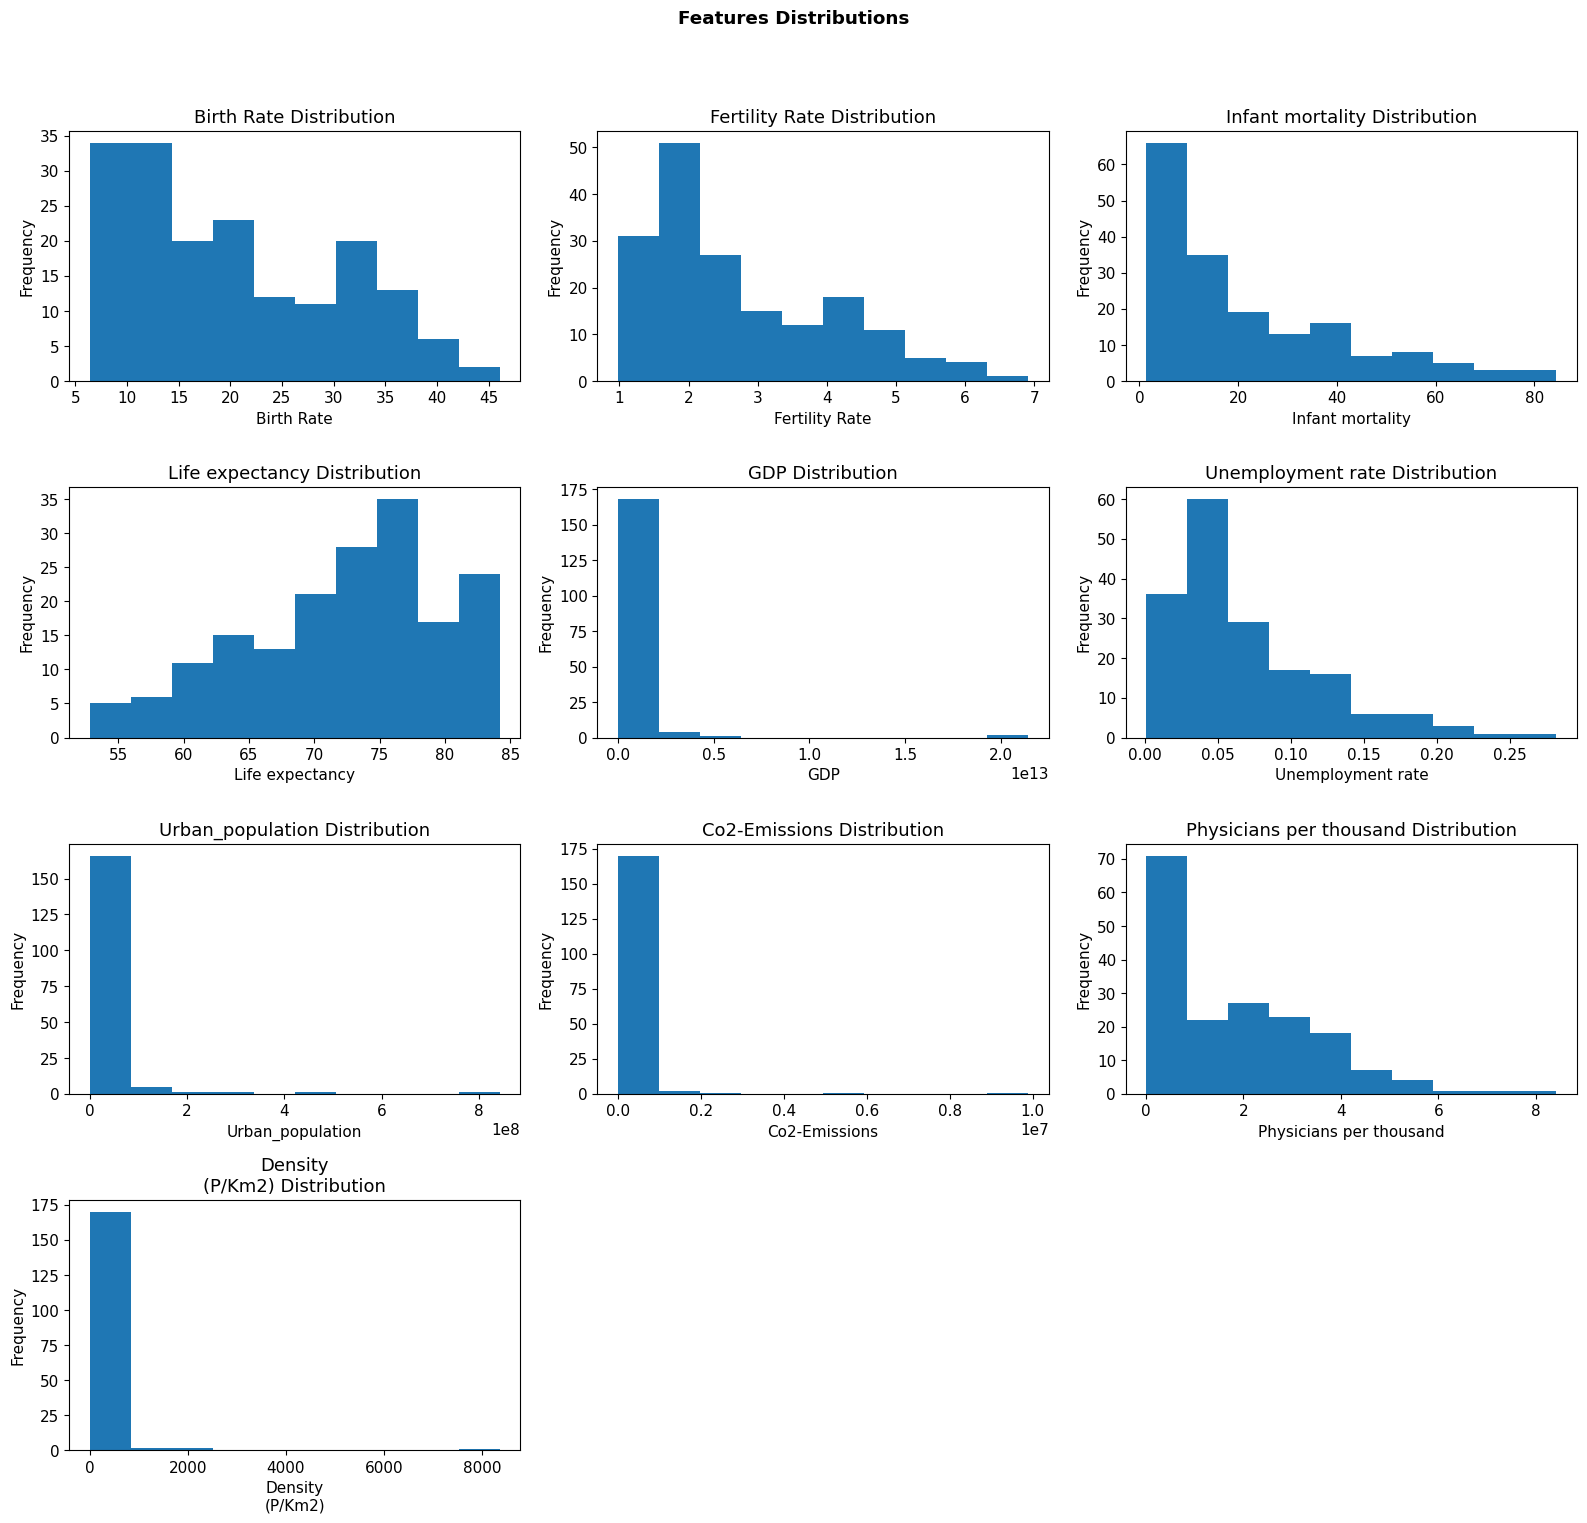

In [13]:
# Dynamically calculate rows needed for 3 columns
n_cols = len(df_cleaned.columns)
n_rows = math.ceil(n_cols / 3) 

fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
fig.suptitle("Features Distributions", fontweight="bold")
axes = axes.flatten()

for idx, col in enumerate(df_cleaned.columns):
    axes[idx].hist(df_cleaned[col].dropna()) # .dropna() prevents errors on empty values
    axes[idx].set_title(f"{col} Distribution")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

# Hide any empty subplots if the grid is larger than the column count
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [14]:
import pandas as pd

# Calculate skewness for all numerical features
skewness_values = df_cleaned.skew().sort_values(ascending=False)

# Convert to a DataFrame for a cleaner look
skew_df = pd.DataFrame({'Skewness': skewness_values})

# Add a 'Status' column to flag high skewness
skew_df['Status'] = skew_df['Skewness'].apply(
    lambda x: 'Highly Skewed' if abs(x) > 1 else 'Moderately Skewed' if abs(x) > 0.5 else 'Fairly Symmetric'
)

print("--- Skewness Analysis ---")
print(skew_df)

# Specifically filter for the ones you might want to Log Transform
to_transform = skew_df[skew_df['Skewness'] > 1].index.tolist()
print(f"\nSuggested for Transformation: {to_transform}")

--- Skewness Analysis ---
                          Skewness             Status
Density\n(P/Km2)         10.392247      Highly Skewed
Co2-Emissions             9.243223      Highly Skewed
GDP                       8.172439      Highly Skewed
Urban_population          7.995695      Highly Skewed
Unemployment rate         1.377651      Highly Skewed
Infant mortality          1.152535      Highly Skewed
Physicians per thousand   0.960657  Moderately Skewed
Fertility Rate            0.938690  Moderately Skewed
Birth Rate                0.563168  Moderately Skewed
Life expectancy          -0.564309  Moderately Skewed

Suggested for Transformation: ['Density\n(P/Km2)', 'Co2-Emissions', 'GDP', 'Urban_population', 'Unemployment rate', 'Infant mortality']


* The features are mostly right skewed except for life expectancy.
* GDP, Density, Urban Population and CO2-Emmissions all have massive outliers.
* This is important to check before PCA as PCA is sensitive to outliers because it uses variance which uses the squared distance from the means. If you square a massive outlier, it'll have massive mathematical weight which in turn will make the PCA focus more on noise rather than actual valuable information.
* Density, CO2, GDP, Urban Population, Unemployment rate, and Infant Mortality are all highly skewed.
* Skewness is also important to check as if there are highly skewed features, it will violate linearity assumptions and the mean will become unrepresentative.

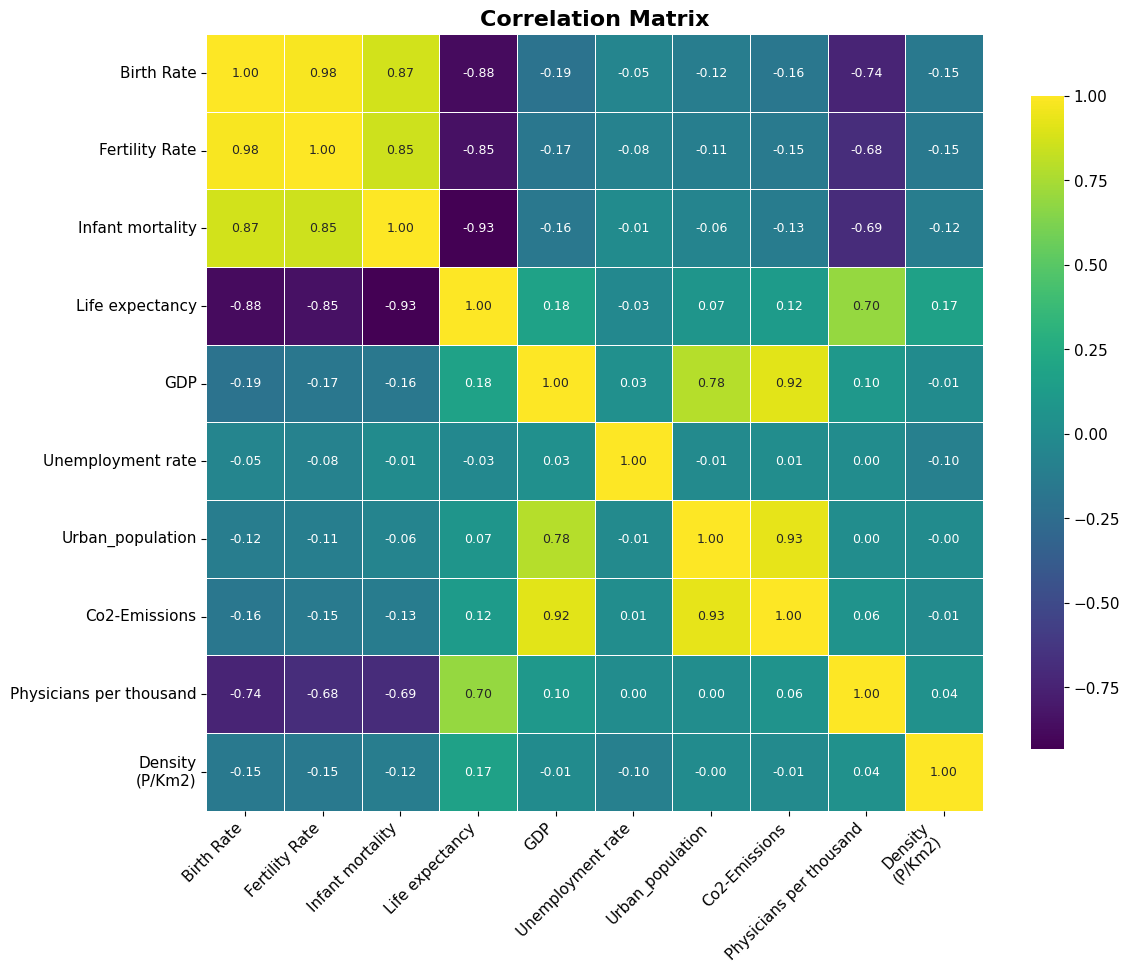

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.90)
  r = +0.981 | Birth Rate  <-->  Fertility Rate
  r = -0.932 | Infant mortality  <-->  Life expectancy
  r = +0.926 | Urban_population  <-->  Co2-Emissions
  r = +0.917 | GDP  <-->  Co2-Emissions

Total highly correlated pairs (|r| > 0.90): 4


In [15]:
# Increase the figure size significantly to fit 10 features comfortably
plt.figure(figsize=(12, 10))

# Get the correlation matrix
corr = df_cleaned.corr()

# fix: use fmt='.2f' to control decimal points and adjust annot_kws for font size
sns.heatmap(
    corr, 
    cmap='viridis', 
    annot=True, 
    fmt='.2f',       # Limits to 2 decimal places to prevent text overlap
    square=True, 
    linewidths=.5,   # Adds small lines between cells for clarity
    cbar_kws={"shrink": .8}, # Scales the color bar
    annot_kws={"size": 9}    # Shrinks the font size of the numbers inside
)

plt.title('Correlation Matrix', fontsize=16, fontweight='bold')

# Rotate labels to prevent overlap
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Report highly correlated pairs
print("=" * 70)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.90)")
print("=" * 70)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, r in high_corr[:15]:
    print(f"  r = {r:+.3f} | {feat1}  <-->  {feat2}")

print()
print(f"Total highly correlated pairs (|r| > 0.90): {len(high_corr)}")

* Birth Rate and Fertility Rate are highly positively correlated, since birth rate focuses on total population and fertility rate focuses on women of childbearing age, both are key indicators of population growth.
* Infant Mortality and Life Expectancy are highly negatively correlated since if life expectancy is high then infant mortality which is measured by the number of infants that die before their first birthday will be lower, but if infant mortality is high then life expectancy will get lower.
* Urban Population and CO2-Emissions are highly positively correlated as the more dense a human population is in one place, the more carbon dioxide will be created in that place too.
* GDP and CO2 emissions are highly positively correlated probably because of fossil fuels, since economic growth are traditionally fueled by energy intensive activities that emit CO2, i.e. Oil and Gas Export, Transportation and Logistics, Construction, Manufacturing and etc.

### Principal Component Analysis

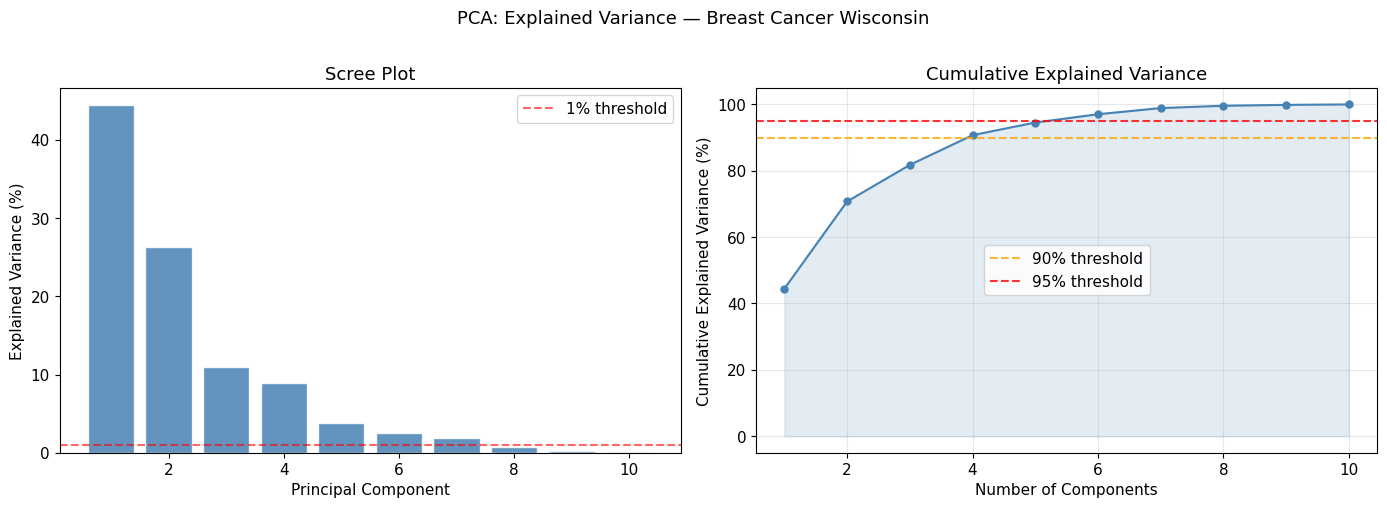

EXPLAINED VARIANCE BY COMPONENT
  PC01: 44.44%  |  Cumulative:  44.44%
  PC02: 26.30%  |  Cumulative:  70.74%
  PC03: 11.02%  |  Cumulative:  81.76%
  PC04:  8.97%  |  Cumulative:  90.73%
  PC05:  3.81%  |  Cumulative:  94.54%
  PC06:  2.50%  |  Cumulative:  97.04%
  PC07:  1.86%  |  Cumulative:  98.90%
  PC08:  0.69%  |  Cumulative:  99.59%
  PC09:  0.27%  |  Cumulative:  99.86%
  PC10:  0.14%  |  Cumulative: 100.00%

  Components needed to explain 90% of variance: 4
  Components needed to explain 95% of variance: 6
  Compression ratio (90% threshold): 4/10 = 40.0%


In [16]:
# Fit PCA retaining all components first
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# --- Scree plot and cumulative explained variance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
components = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca_full.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% threshold')
axes[0].legend()

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA: Explained Variance — Breast Cancer Wisconsin', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Report
print("=" * 70)
print("EXPLAINED VARIANCE BY COMPONENT")
print("=" * 70)
cumulative = 0
for i, var in enumerate(pca_full.explained_variance_ratio_[:10]):
    cumulative += var
    print(f"  PC{i+1:02d}: {var*100:5.2f}%  |  Cumulative: {cumulative*100:6.2f}%")

n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print()
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")
print(f"  Compression ratio (90% threshold): {n_90}/10 = {n_90/10:.1%}")

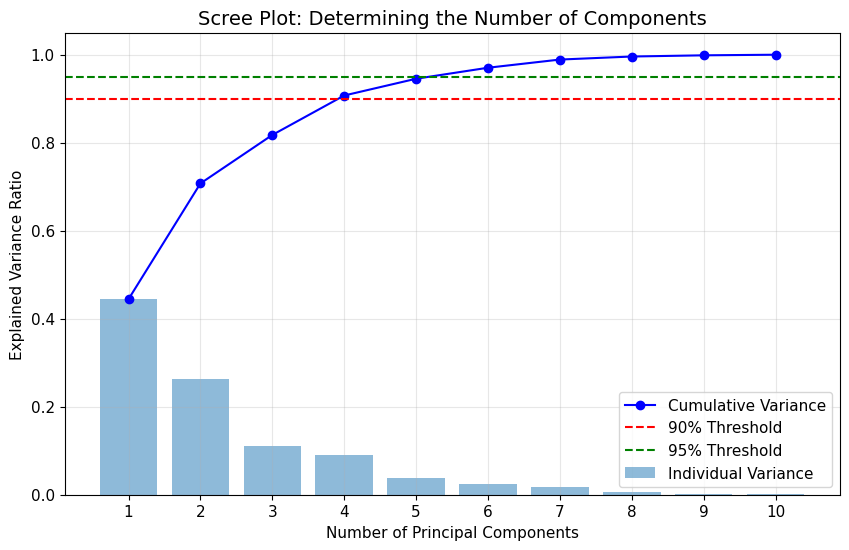

In [17]:
# 1. Calculate cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot the cumulative variance
plt.plot(range(1, 11), cum_var, marker='o', linestyle='-', color='b', label='Cumulative Variance')

# Plot the individual variance (step plot looks best here)
plt.bar(range(1, 11), pca_full.explained_variance_ratio_, alpha=0.5, align='center', label='Individual Variance')

# 3. Add Threshold Lines
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Threshold')

# 4. Formatting
plt.title('Scree Plot: Determining the Number of Components', fontsize=14)
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

In [18]:
# Check eigenvalues
eigenvalues = pca_full.explained_variance_
print(f"Eigenvalues: {eigenvalues}")

Eigenvalues: [4.46977653 2.64504329 1.10852184 0.90181795 0.38316044 0.25158606
 0.18696713 0.06962822 0.02734915 0.01362067]


* I need 3 components to get 80% cumulative total, 4 to get 90% and 6 to get 95%
* I have decided to use 4 components, even though Component 4 has a 0.902 eigenvalue, it still matters as it's the last step to getting 90%, which is much more important for a complete analysis rather than maintaining the >1 eigenvalue threshold.
* Furthermore looking at the data, at around the 4th component the bars become very small, which means this is also the elbow. NOTE: This is only determined by sight

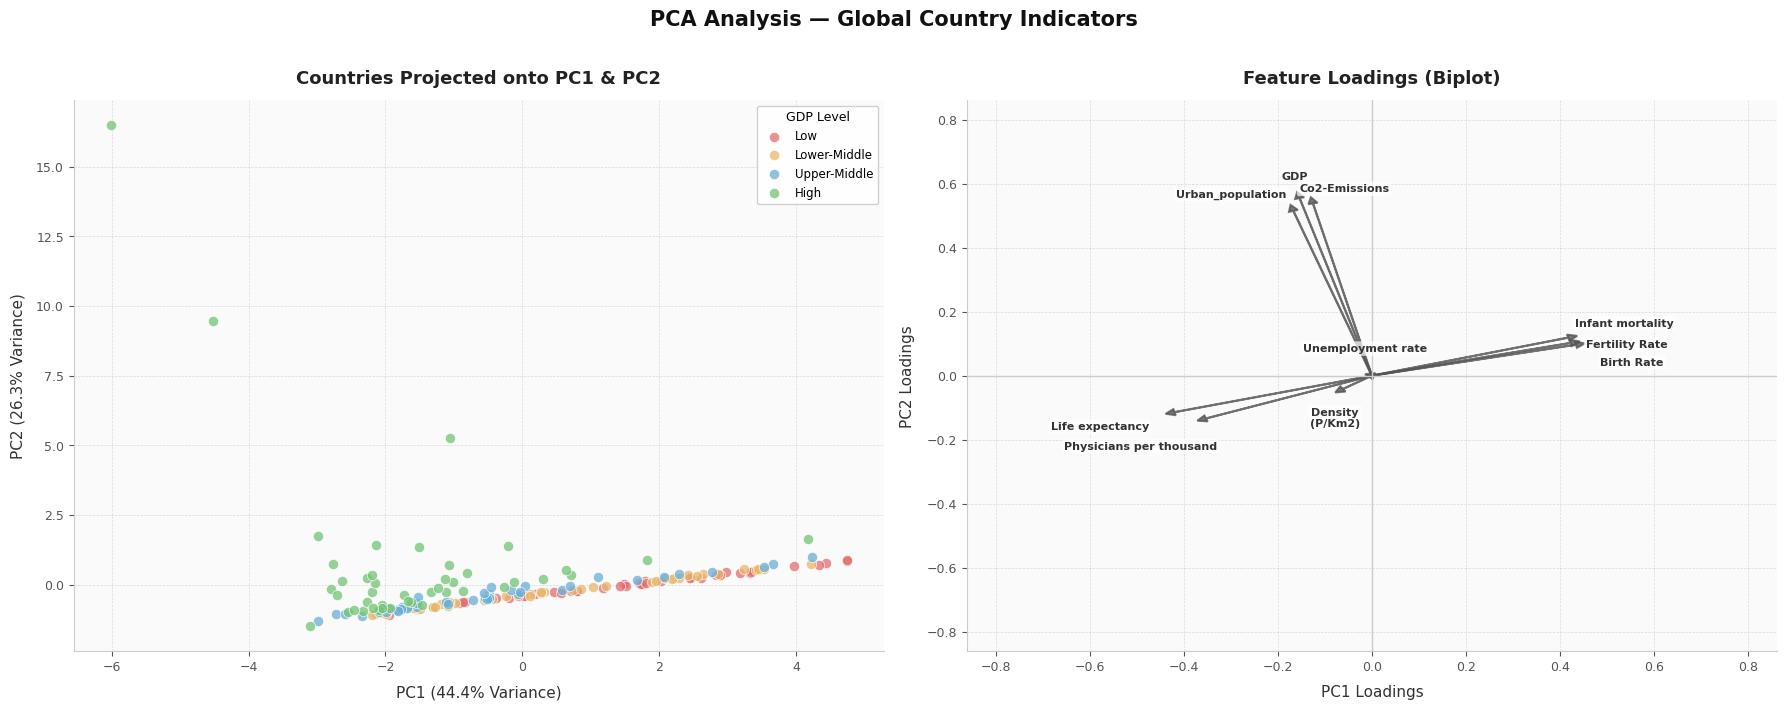

FEATURE LOADINGS SORTED BY PC1
                              PC1       PC2
Birth Rate               0.453211  0.101049
Fertility Rate           0.442032  0.107055
Infant mortality         0.436516  0.124375
Unemployment rate       -0.014727  0.004690
Density\n(P/Km2)        -0.078046 -0.052659
Urban_population        -0.129778  0.557744
Co2-Emissions           -0.158997  0.574188
GDP                     -0.173042  0.534056
Physicians per thousand -0.371266 -0.140855
Life expectancy         -0.438689 -0.119323
PCA 2D PROJECTION SUMMARY
  PC1 explains: 44.44% of variance
  PC2 explains: 26.30% of variance
  Combined:     70.74%

Top 5 features contributing most to PC1 (by absolute loading):
  +0.453  Birth Rate
  +0.442  Fertility Rate
  -0.439  Life expectancy
  +0.437  Infant mortality
  -0.371  Physicians per thousand


In [19]:
# 1. Prepare Development Levels
quartiles = pd.qcut(df_cleaned['GDP'], 4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

# Define y and labels based on your actual data
y = quartiles.values

colors = {'Low': '#e07070', 'Lower-Middle': '#e8b86d', 'Upper-Middle': '#6baed6', 'High': '#74c476'}
labels_map = {'Low': 'Low', 'Lower-Middle': 'Lower-Middle', 'Upper-Middle': 'Upper-Middle', 'High': 'High'}

# 2. Fit PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 3. Create Loadings
feature_cols = df_cleaned.columns.tolist()
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)

# 4. Create Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='white')
fig.patch.set_facecolor('white')

# ── Plot 1: Scatter ──────────────────────────────────────────────
colors = {
    'Low':          '#e07070',
    'Lower-Middle': '#e8b86d',
    'Upper-Middle': '#6baed6',
    'High':         '#74c476'
}

for level, color in colors.items():
    mask = (quartiles == level)
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=color, label=level,
        alpha=0.75, s=55,
        edgecolors='white', linewidth=0.6,
        zorder=3
    )

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)',
                   fontsize=11, color='#333333', labelpad=8)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)',
                   fontsize=11, color='#333333', labelpad=8)
axes[0].set_title('Countries Projected onto PC1 & PC2',
                  fontsize=13, fontweight='bold', color='#222222', pad=12)
axes[0].legend(
    title="GDP Level", title_fontsize=9,
    fontsize=8.5, framealpha=0.9,
    edgecolor='#cccccc', facecolor='white'
)
axes[0].set_facecolor('#fafafa')
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].spines[['left', 'bottom']].set_color('#cccccc')
axes[0].tick_params(colors='#555555', labelsize=9)

# ── Plot 2: Biplot ───────────────────────────────────────────────
label_offsets = {
    'Physicians per thousand': (-0.12, -0.08),
    'Unemployment rate':       ( 0.00,  0.08),
    'Co2-Emissions':           ( 0.1,  0.01),
    'Infant mortality':        ( 0.10,  0.04),
    'Fertility Rate':          ( 0.10, -0.01),
    'Birth Rate':              ( 0.10, -0.06),
    'Urban_population':        (-0.17,  0.01),   
    'Life expectancy':         (-0.14, -0.04),
    'Density\n(P/Km2)':        ( 0.00, -0.08),
    'GDP':                     ( 0.01,  0.09),
}

for feat, row in loadings.iterrows():
    axes[1].arrow(
        0, 0, row['PC1'], row['PC2'],
        head_width=0.02, head_length=0.02,
        fc='#555555', ec='#555555',
        lw=1.4, alpha=0.8,
        length_includes_head=True,
        zorder=2
    )
    ox, oy = label_offsets.get(feat, (0.05, 0.05))
    axes[1].text(
        row['PC1'] + ox, row['PC2'] + oy, feat,
        fontsize=8, color='#333333', fontweight='bold',
        ha='center', va='center', zorder=3,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='none', alpha=0.7)
    )

max_val = loadings[['PC1', 'PC2']].abs().max().max()
pad = max_val * 0.5
axes[1].set_xlim(-max_val - pad, max_val + pad)
axes[1].set_ylim(-max_val - pad, max_val + pad)
axes[1].axhline(0, color='#cccccc', linewidth=1)
axes[1].axvline(0, color='#cccccc', linewidth=1)
axes[1].set_xlabel('PC1 Loadings', fontsize=11, color='#333333', labelpad=8)
axes[1].set_ylabel('PC2 Loadings', fontsize=11, color='#333333', labelpad=8)
axes[1].set_title('Feature Loadings (Biplot)',
                  fontsize=13, fontweight='bold', color='#222222', pad=12)
axes[1].set_facecolor('#fafafa')
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines[['left', 'bottom']].set_color('#cccccc')
axes[1].tick_params(colors='#555555', labelsize=9)

plt.suptitle('PCA Analysis — Global Country Indicators',
             fontsize=15, fontweight='bold', color='#111111', y=1.01)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 5. Print Loading Table
print("=" * 40)
print("FEATURE LOADINGS SORTED BY PC1")
print("=" * 40)
loading_table = loadings.sort_values(by='PC1', ascending=False)
print(loading_table[['PC1', 'PC2']].to_string())

print("=" * 70)
print("PCA 2D PROJECTION SUMMARY")
print("=" * 70)
print(f"  PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Combined:     {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print()
print("Top 5 features contributing most to PC1 (by absolute loading):")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
for feat, val in top_pc1.items():
    direction = "+" if loadings.loc[feat, 'PC1'] > 0 else "-"
    print(f"  {direction}{abs(val):.3f}  {feat}")

In [20]:
print("=" * 45)
print("WCSS PER GDP DEVELOPMENT LEVEL")
print("(Lower = Denser, Higher = More Spread Out)")
print("=" * 45)

wcss_results = {}
for level in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = (quartiles == level).values
    points = X_pca_2d[mask]
    centroid = points.mean(axis=0)
    wcss = ((points - centroid) ** 2).sum()
    wcss_results[level] = wcss
    print(f"{level:<20} WCSS = {wcss:.4f}")

print("-" * 45)
densest = min(wcss_results, key=wcss_results.get)
most_spread = max(wcss_results, key=wcss_results.get)
print(f"Most Dense:       {densest}")
print(f"Most Spread Out:  {most_spread}")
print("=" * 45)

WCSS PER GDP DEVELOPMENT LEVEL
(Lower = Denser, Higher = More Spread Out)
Low                  WCSS = 152.5300
Lower-Middle         WCSS = 169.8190
Upper-Middle         WCSS = 150.6187
High                 WCSS = 502.9106
---------------------------------------------
Most Dense:       Upper-Middle
Most Spread Out:  High


* PC1 captures most of the Birth Rate, Fertility Rate, Life Expectancy, Infant Mortality, and Density Variant whereas the PC2 captures the Co2 Emissions, Physicians per thousand and Unemployment rate
* PC1 seems to represent the health of the population, since it captures mostly things that have relations to the country population.
* PC2 however captures the overall economic and urban development status of the country with its features.
* For the group that clusters the most, I used WCSS since it's hard to determine using eyesight since I'm nowhere near omnipotent yet to decipher such small pixels, The most dense according to the WCSS is the upper middle class and the most spread out is the High Class, which makes a lot of sense since it has the most amount of outliers and the one that doesn't follow the thin line that every class seems to follow

MSE PER NUMBER OF COMPONENTS
k= 1  MSE=0.555577
k= 2  MSE=0.292584
k= 3  MSE=0.182365
k= 4  MSE=0.092698
k= 6  MSE=0.029586
k= 8  MSE=0.004074
k=10  MSE=0.000000


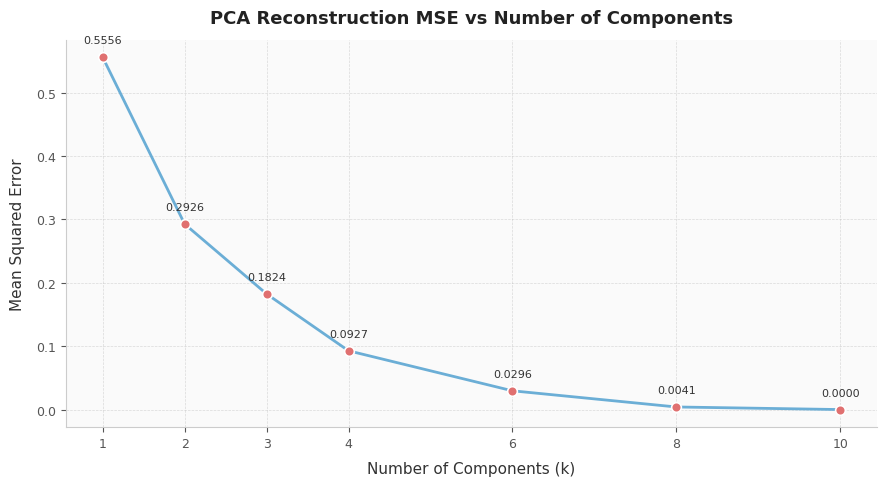


TOP 5 COUNTRIES — HIGHEST MSE (k=2)
 Country       MSE
     156 13.996706
     186  2.125179
     161  1.901195
      95  1.472875
      77  1.265305

TOP 5 COUNTRIES — LOWEST MSE (k=2)
 Country      MSE
     157 0.028150
     100 0.024848
      41 0.023651
      49 0.020506
      16 0.018254


In [21]:
# ── Part 1: MSE vs Number of Components ──────────────────────────
k_values = [1, 2, 3, 4, 6, 8, 10]
mse_values = []

print("=" * 40)
print("MSE PER NUMBER OF COMPONENTS")
print("=" * 40)

for k in k_values:
    pca_k = PCA(n_components=k, random_state=42)
    X_reduced = pca_k.fit_transform(X_scaled)
    X_reconstructed = pca_k.inverse_transform(X_reduced)
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_values.append(mse)
    print(f"k={k:>2}  MSE={mse:.6f}")

# ── Plot MSE vs Components ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.plot(k_values, mse_values, marker='o', color='#6baed6',
        linewidth=2, markersize=7, markerfacecolor='#e07070',
        markeredgecolor='white', markeredgewidth=1.2, zorder=3)

for k, mse in zip(k_values, mse_values):
    ax.annotate(f'{mse:.4f}', xy=(k, mse), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=8, color='#333333')

ax.set_xlabel('Number of Components (k)', fontsize=11, color='#333333', labelpad=8)
ax.set_ylabel('Mean Squared Error', fontsize=11, color='#333333', labelpad=8)
ax.set_title('PCA Reconstruction MSE vs Number of Components',
             fontsize=13, fontweight='bold', color='#222222', pad=12)
ax.set_xticks(k_values)
ax.set_facecolor('#fafafa')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
ax.tick_params(colors='#555555', labelsize=9)
plt.tight_layout()
plt.show()

# ── Part 2: Per-country MSE at k=2 ───────────────────────────────
pca_2 = PCA(n_components=2, random_state=42)
X_reduced_2 = pca_2.fit_transform(X_scaled)
X_reconstructed_2 = pca_2.inverse_transform(X_reduced_2)

# MSE per country (row-wise)
per_country_mse = ((X_scaled - X_reconstructed_2) ** 2).mean(axis=1)

# Attach to country names
country_mse_df = pd.DataFrame({
    'Country': df_cleaned.index,
    'MSE': per_country_mse
}).sort_values('MSE', ascending=False).reset_index(drop=True)

print()
print("=" * 40)
print("TOP 5 COUNTRIES — HIGHEST MSE (k=2)")
print("=" * 40)
print(country_mse_df.head(5).to_string(index=False))

print()
print("=" * 40)
print("TOP 5 COUNTRIES — LOWEST MSE (k=2)")
print("=" * 40)
print(country_mse_df.tail(5).to_string(index=False))


##### The countries with high reconstruction error particularly the country 156, 186, 161, 95, and 77 all have massive MSE meaning they're far from the reality or the mean of most countries, their socioeconomic profiles cannot be adequately captured by only two components, meaning they have extreme values or contradictory values and combinations of indicators i.e. High GDP with Poor Health or Low GDP with High Co2 Emissions. Therefore we can conclude that high reconstruction error is a signal of uniqueness and outlier behaviour, deviating from the global socioeconomic norm.

### t-SNE and UMAP

t-SNE: EXPLORING PERPLEXITY SENSITIVITY

t-SNE key parameters:
  perplexity: roughly the number of effective neighbors (~5-50)
  n_iter:     number of optimization steps (more = better convergence)
  random_state: always set for reproducibility

  Fitting t-SNE with perplexity=5... done
  Fitting t-SNE with perplexity=15... done
  Fitting t-SNE with perplexity=30... done
  Fitting t-SNE with perplexity=50... done


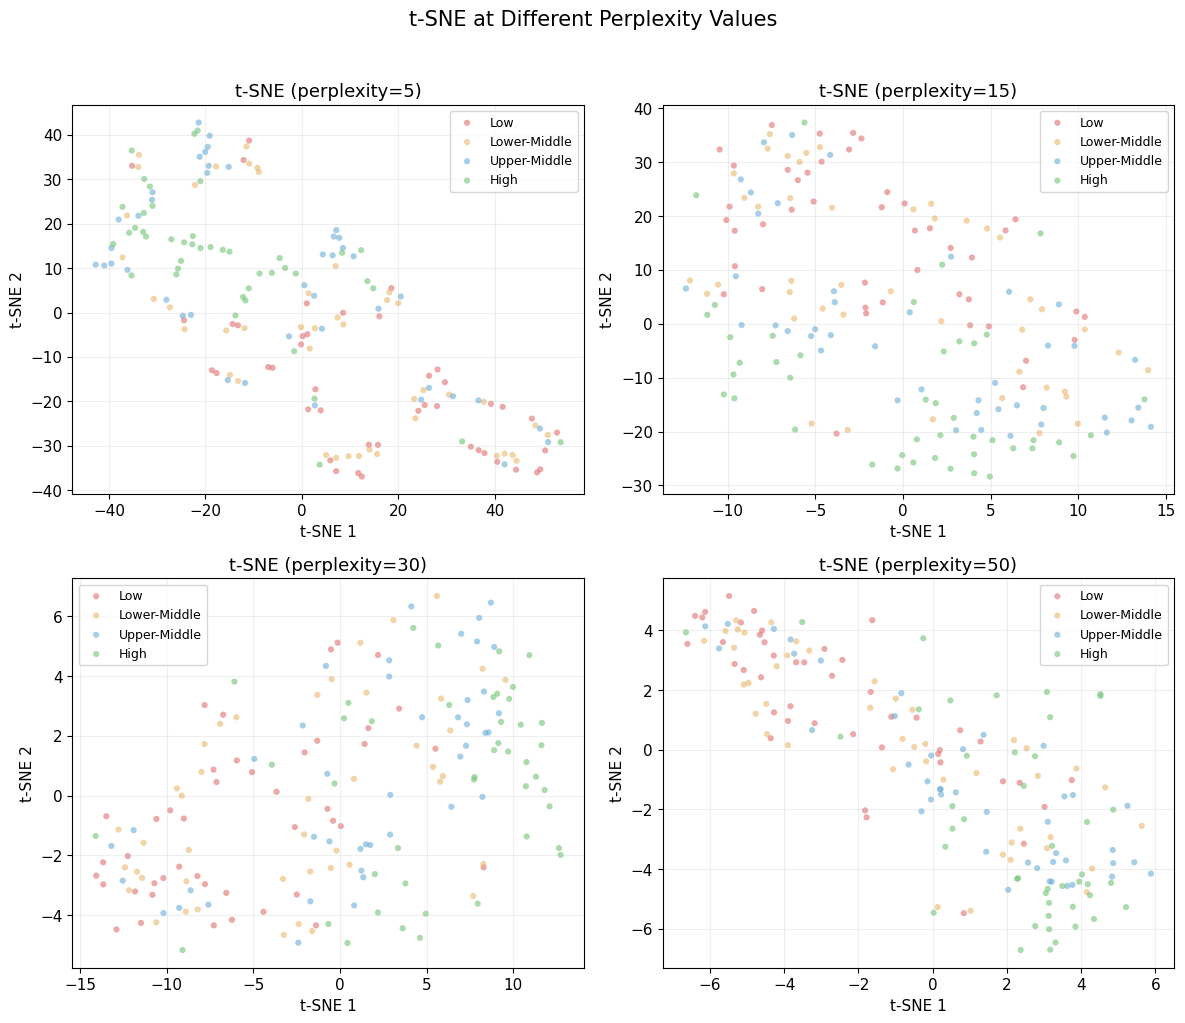

In [27]:
print("=" * 70)
print("t-SNE: EXPLORING PERPLEXITY SENSITIVITY")
print("=" * 70)
print()
print("t-SNE key parameters:")
print("  perplexity: roughly the number of effective neighbors (~5-50)")
print("  n_iter:     number of optimization steps (more = better convergence)")
print("  random_state: always set for reproducibility")
print()

# Try three perplexity values
perplexities = [5, 15, 30, 50]
tsne_results = {}

for perp in perplexities:
    print(f"  Fitting t-SNE with perplexity={perp}...", end=" ")
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                random_state=42, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(X_scaled)
    print("done")

# Plot all four in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # Changed to 2x2
axes_flat = axes.flatten() # Flatten to 1D to loop easily

for ax, perp in zip(axes_flat, perplexities):
    Z = tsne_results[perp]
    for cls in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=cls,
                   alpha=0.6, s=20, edgecolors='none')
    
    ax.set_title(f't-SNE (perplexity={perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('t-SNE at Different Perplexity Values',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
print("=" * 75)
print(f"{'Perplexity':<12} {'Cluster Separation':<22} {'Observation'}")
print("=" * 75)
print(f"{'5':<12} {'Poor':<22} Promising for the High GDP but only shows small micro clusters in others")
print(f"{'15':<12} {'Poor':<22} A bit more grouping here but all over, still a lot of overlapping")
print(f"{'30':<12} {'Poor':<22} Red and Green has a good cluster but still a lot of overlap")
print(f"{'50':<12} {'Poor':<22} All groups are in one being eggplant shaped cluster with a bit of grouping with green and red")
print("=" * 75)
print()
print("Overall: GDP quartile labels do not separate well in t-SNE at any perplexity, suggesting GDP level alone is not a strong separator in the underlying") 
print("high-dimensional structure of this dataset.")

Perplexity   Cluster Separation     Observation
5            Poor                   Promising for the High GDP but only shows small micro clusters in others
15           Poor                   A bit more grouping here but all over, still a lot of overlapping
30           Poor                   Red and Green has a good cluster but still a lot of overlap
50           Poor                   All groups are in one being eggplant shaped cluster with a bit of grouping with green and red

Overall: GDP quartile labels do not separate well in t-SNE at any perplexity, suggesting GDP level alone is not a strong separator in the underlying
high-dimensional structure of this dataset.


 The best perplexity for me is 15, It's quite hard to use t-SNE since it uses sight, the way I understand perplexity is kind of like the epsilon in DBScan wherein low perplexity = low eps and high perplexity = high eps, but the difference being the adaptability of perplexity wherein it handles varying densities to visualize clusters in the human eye, it also helps with visualizing which data points are actually closer in high dimensions like 3D or more by making sure they remain close in the visualization. The key is to find the balance between low perplexity and high perplexity, too low will make the data look like its full of noise and too high will make the data look like one blob of data points.

UMAP: EXPLORING n_neighbors AND min_dist SENSITIVITY

  Fitting UMAP with n_neighbors=5, min_dist=0.1... done
  Fitting UMAP with n_neighbors=15, min_dist=0.1... done
  Fitting UMAP with n_neighbors=50, min_dist=0.1... done
  Fitting UMAP with n_neighbors=15, min_dist=0.0... done
  Fitting UMAP with n_neighbors=15, min_dist=0.1... done
  Fitting UMAP with n_neighbors=15, min_dist=0.5... done


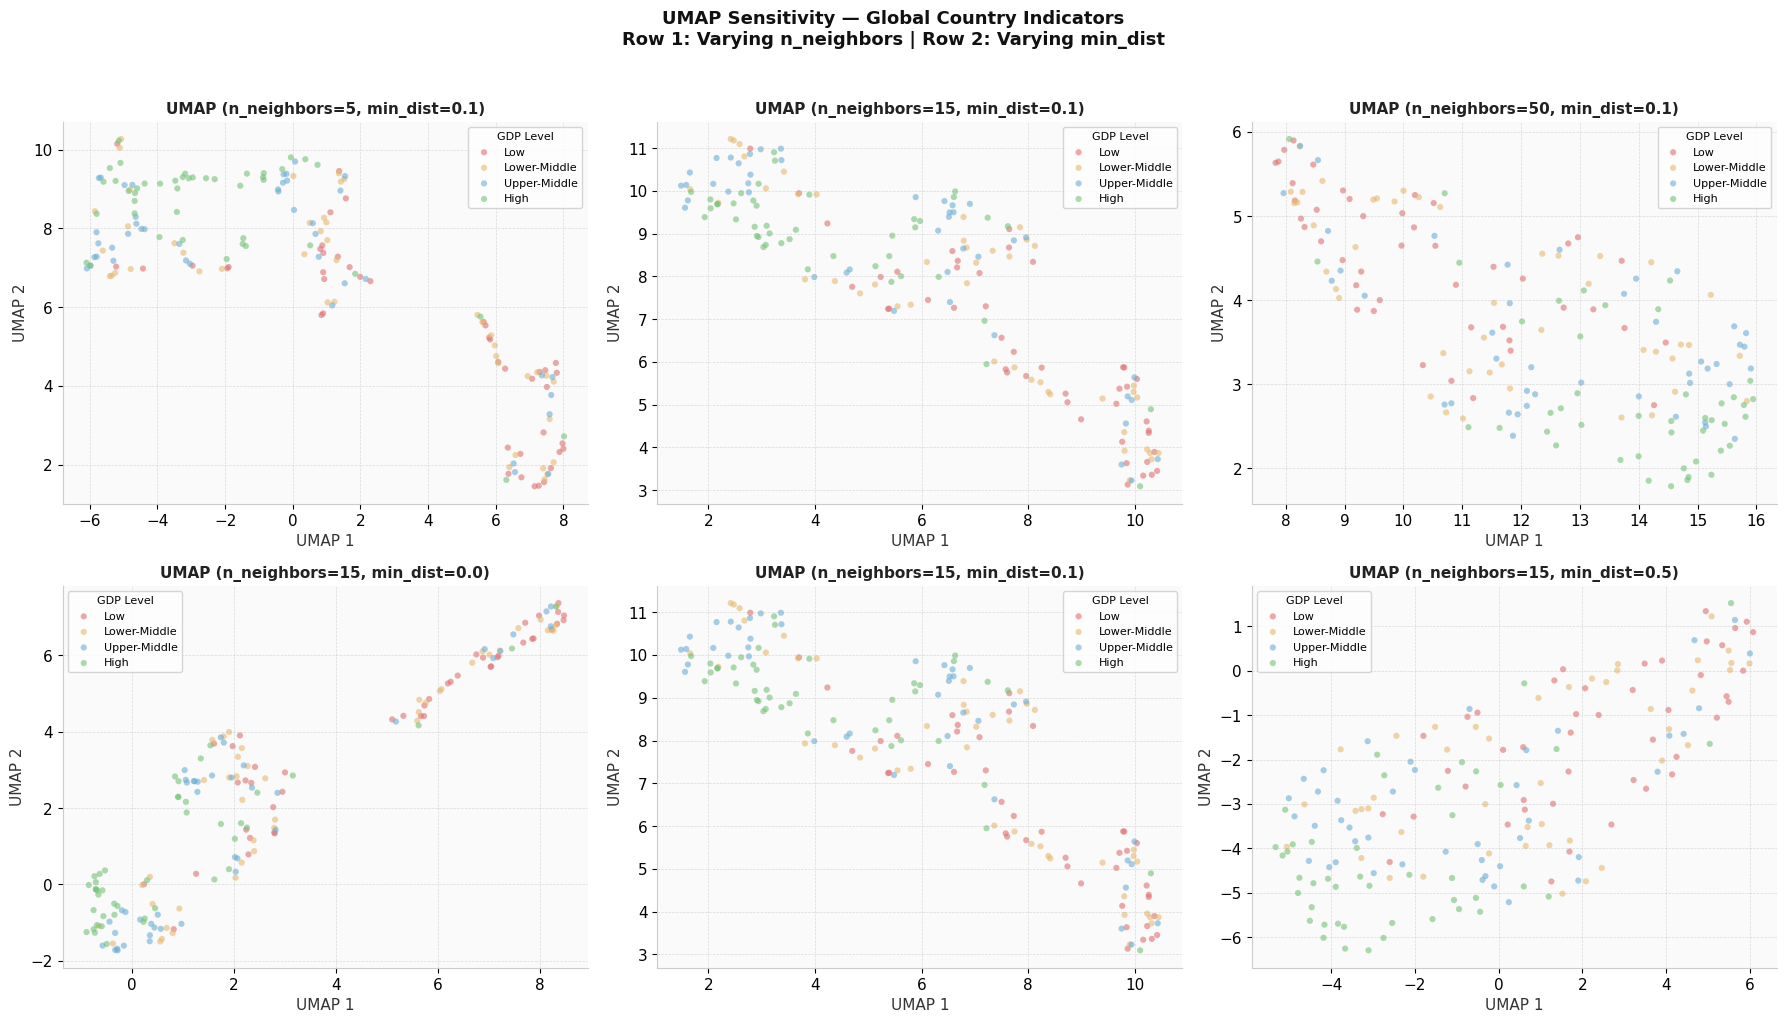

In [24]:
if UMAP_AVAILABLE:
    print("=" * 70)
    print("UMAP: EXPLORING n_neighbors AND min_dist SENSITIVITY")
    print("=" * 70)
    print()

    # ── Row 1: Vary n_neighbors (min_dist fixed at 0.1) ──────────────
    neighbor_values = [5, 15, 50]
    umap_results_neighbors = {}
    for n in neighbor_values:
        print(f"  Fitting UMAP with n_neighbors={n}, min_dist=0.1...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=n,
                            min_dist=0.1, random_state=42)
        umap_results_neighbors[n] = reducer.fit_transform(X_scaled)
        print("done")

    # ── Row 2: Vary min_dist (n_neighbors fixed at 15) ───────────────
    mindist_values = [0.0, 0.1, 0.5]
    umap_results_mindist = {}
    for md in mindist_values:
        print(f"  Fitting UMAP with n_neighbors=15, min_dist={md}...", end=" ")
        reducer = umap.UMAP(n_components=2, n_neighbors=15,
                            min_dist=md, random_state=42)
        umap_results_mindist[md] = reducer.fit_transform(X_scaled)
        print("done")

    # ── Plot 2 rows x 3 cols ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
    fig.patch.set_facecolor('white')

    # Row 1: n_neighbors sensitivity
    for ax, n in zip(axes[0], neighbor_values):
        Z = umap_results_neighbors[n]
        for cls in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
            mask = (y == cls)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=colors[cls], label=cls,
                       alpha=0.6, s=20, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors={n}, min_dist=0.1)',
                     fontsize=11, fontweight='bold', color='#222222')
        ax.set_xlabel('UMAP 1', color='#333333')
        ax.set_ylabel('UMAP 2', color='#333333')
        ax.legend(fontsize=8, title='GDP Level', title_fontsize=8)
        ax.set_facecolor('#fafafa')
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#cccccc')

    # Row 2: min_dist sensitivity
    for ax, md in zip(axes[1], mindist_values):
        Z = umap_results_mindist[md]
        for cls in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
            mask = (y == cls)
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=colors[cls], label=cls,
                       alpha=0.6, s=20, edgecolors='none')
        ax.set_title(f'UMAP (n_neighbors=15, min_dist={md})',
                     fontsize=11, fontweight='bold', color='#222222')
        ax.set_xlabel('UMAP 1', color='#333333')
        ax.set_ylabel('UMAP 2', color='#333333')
        ax.legend(fontsize=8, title='GDP Level', title_fontsize=8)
        ax.set_facecolor('#fafafa')
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#cccccc')

    plt.suptitle('UMAP Sensitivity — Global Country Indicators\n'
                 'Row 1: Varying n_neighbors | Row 2: Varying min_dist',
                 fontsize=13, fontweight='bold', color='#111111', y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("UMAP not available. Install with: pip install umap-learn")
    print("Skipping UMAP section.")

* n_neigbors control how much of the global and local structure UMAP pays attention to, it asks how many nearby points should I consider when learning the structure? A small value i.e. 5 only looks at very close neighbors whereas a high value i.e. 50 looks at more neighbors and sees the bigger picture.
* It's kind of like a zoom knob where if you turn to a small n_neigbor value it zooms in and when you turn to a high n_neighbor value it zooms out.
* min_dist however controls how tightly packed the points are in the final 2D layout, 0.0 is small and 0.5 is large, think of it like the infinity that Gojo has in Jujutsu Kaisen, wherein there's a minimum distance between each point reducing the amount of confusion when looking at the dataset, since it lowers the chance of a data point being too close to another.
* n_neigbors chaning made the groupings change where at value 5 there are tiny fragmented  groups which are very hard to read, in 15 which in my opinion is the best balance you can see the groups that are actually close and the groups that are fairly far away, and lastly the  value 50 wherein it joins into two big blobs which for me is unreliable, the distance changed how the datapoints look in the graph wherein 0.0 is too compact and 0.5 is too spread out.

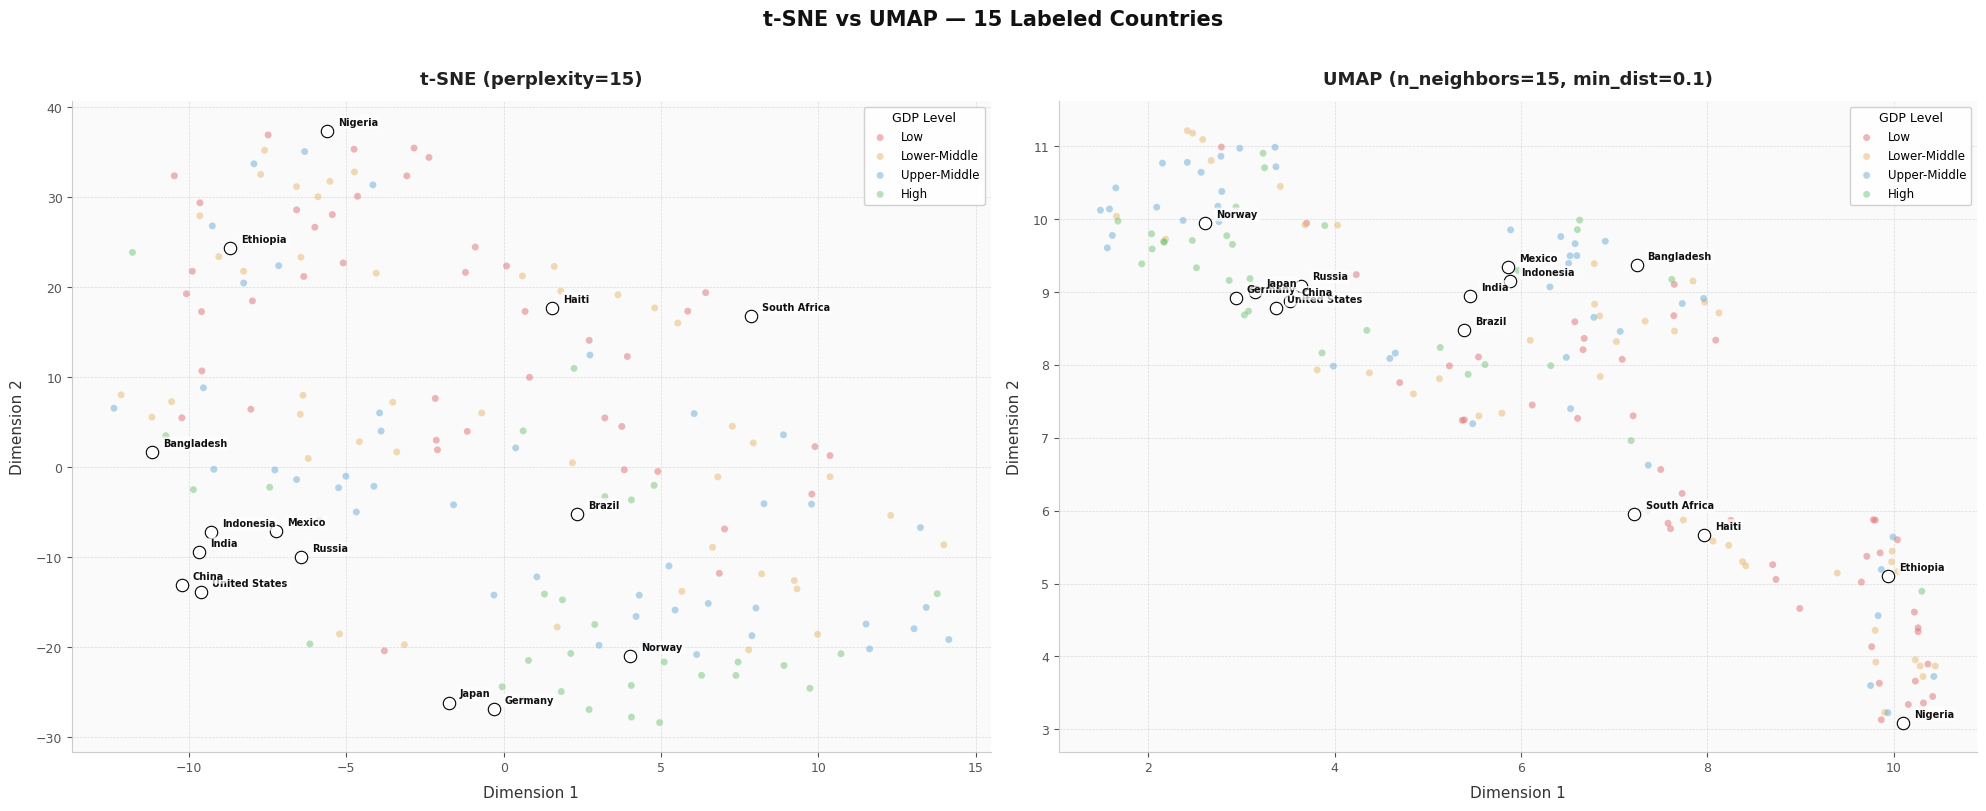


Note: 'Russian Federation' is labeled as 'Russia' in this dataset.
All 15 target countries found and labeled.


In [25]:
target_countries = [
    'United States', 'China', 'India', 'Brazil', 'Germany',
    'Nigeria', 'Ethiopia', 'Japan', 'Russia',
    'South Africa', 'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti'
]

# Get aligned indices from cleaned data
country_list = df[df.index.isin(df_cleaned.index)]['Country'].tolist()
label_indices = {}
for c in target_countries:
    if c in country_list:
        label_indices[c] = country_list.index(c)

# Best t-SNE and UMAP results
Z_tsne = tsne_results[15]
Z_umap = umap_results_neighbors[15]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')
fig.patch.set_facecolor('white')

for ax, Z, title in zip(axes,
                         [Z_tsne, Z_umap],
                         ['t-SNE (perplexity=15)', 'UMAP (n_neighbors=15, min_dist=0.1)']):

    # Plot all points by GDP level
    for cls in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=cls,
                   alpha=0.5, s=25, edgecolors='none', zorder=2)

    # Highlight and label target countries
    for country, idx in label_indices.items():
        x, y_pos = Z[idx, 0], Z[idx, 1]
        ax.scatter(x, y_pos,
                   s=80, zorder=4,
                   edgecolors='black', linewidth=0.8,
                   c='white')
        ax.annotate(
            country,
            xy=(x, y_pos),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=7, color='#111111', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='none', alpha=0.7),
            zorder=5
        )

    ax.set_title(title, fontsize=13, fontweight='bold', color='#222222', pad=12)
    ax.set_xlabel('Dimension 1', fontsize=11, color='#333333', labelpad=8)
    ax.set_ylabel('Dimension 2', fontsize=11, color='#333333', labelpad=8)
    ax.legend(title='GDP Level', fontsize=8.5, title_fontsize=9,
              framealpha=0.9, edgecolor='#cccccc', facecolor='white')
    ax.set_facecolor('#fafafa')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)

plt.suptitle('t-SNE vs UMAP — 15 Labeled Countries',
             fontsize=15, fontweight='bold', color='#111111', y=1.01)
plt.tight_layout()
plt.show()

print()
print("Note: 'Russian Federation' is labeled as 'Russia' in this dataset.")
print("All 15 target countries found and labeled.")

* I honestly didn't know what to expect, I can't interpret it well since all the 10 features are compressed down to 2 dimensions, although what I can see is that Japan and Germany, United States, Russia and China, India, Mexico and Indonesia are in close proximity in both t-SNE and UMAP.
* Nigeria and Ethiopia are somehow always far from the clusters.

### Comparison and Recommendations

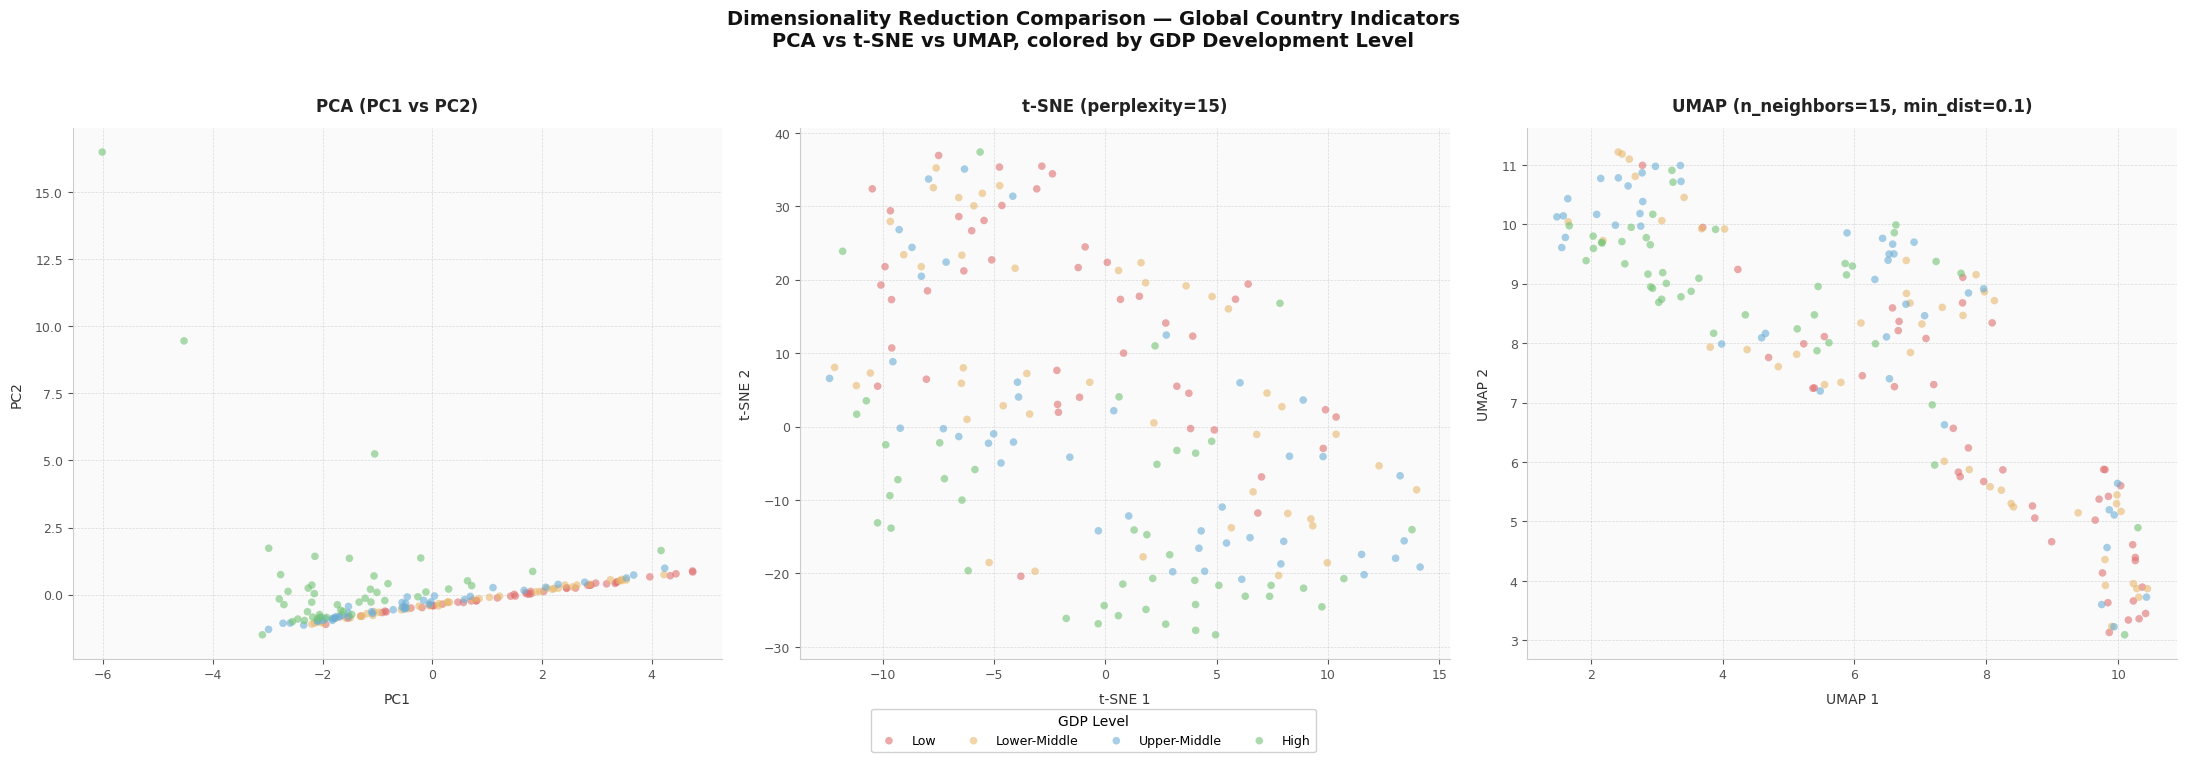

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor='white')
fig.patch.set_facecolor('white')

# ── Data for each plot ────────────────────────────────────────────
plot_configs = [
    (X_pca_2d,        'PCA (PC1 vs PC2)',                  'PC1',    'PC2'),
    (Z_tsne,'t-SNE (perplexity=15)',              't-SNE 1','t-SNE 2'),
    (umap_results_neighbors[15] if UMAP_AVAILABLE
     else tsne_results[30],
     'UMAP (n_neighbors=15, min_dist=0.1)' if UMAP_AVAILABLE
     else 't-SNE (perplexity=30)',
     'UMAP 1' if UMAP_AVAILABLE else 't-SNE 1',
     'UMAP 2' if UMAP_AVAILABLE else 't-SNE 2'),
]

for ax, (Z, title, xlabel, ylabel) in zip(axes, plot_configs):
    for cls in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        mask = (y == cls)
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=colors[cls], label=cls,
                   alpha=0.6, s=30, edgecolors='none', zorder=2)

    ax.set_title(title, fontsize=12, fontweight='bold', color='#222222', pad=12)
    ax.set_xlabel(xlabel, fontsize=10, color='#333333', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=10, color='#333333', labelpad=8)
    ax.set_facecolor('#fafafa')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='#aaaaaa')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)

# ── Shared legend ─────────────────────────────────────────────────
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels_leg,
    title='GDP Level', title_fontsize=10,
    fontsize=9, framealpha=0.9,
    edgecolor='#cccccc', facecolor='white',
    loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, -0.05)
)

plt.suptitle('Dimensionality Reduction Comparison — Global Country Indicators\n'
             'PCA vs t-SNE vs UMAP, colored by GDP Development Level',
             fontsize=14, fontweight='bold', color='#111111', y=1.02)
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

if not UMAP_AVAILABLE:
    print("Note: UMAP not available — third plot shows t-SNE (perplexity=30) instead.")

* The graph that seperates the development group most clearly for me is the UMAP method, I can see distinct blobs and clusters with some outliers
* The most meaningful axes here is the PCA axes most obviously the PC1 axes, PC1 must be the health level of countries since there are clusters of high and upper middle gdp (-2 to 0) level in one place with some outliers and same with both low and lower middle (0 to 4) in one place with also some outliers
* If I had to rank the methods by trust I would go with PCA as my most trusted method followed by UMAP and then t-SNE, my reasoning for this is PCA is the most compatible for new data as all you need to do is to scale and then put into the same axes, I think pca.transform(new_country) would work, which makes it super easy to use with new data.
* Next is UMAP, which is lower than PCA because it can support new data like PCA but the layout might change depending on the new data since UMAP builds a graph of relationships between points that could affect new points, but this only happens if you fit transform again which you most likely would do since we want to see how the new country affects the other countries, although you can also just use transform so that new countries get places relative to the existing map.
* The last placer is t-SNE which doesn't have the transform method for new data, since it optimizes new points simultaneously, every point depends on every other point, it doesn't have a specific formula that it learned, it's more of "arrange these specific points so that similar ones are close together"

#### 1. What method do you recommend and why?

I recommend the PCA method since it's easily interpretable even by non-technical policy team and even civilians by just labelling the axes with the PC1 axis being the health axis of the countries and the PC2 axis being the economic and urban development of countries, moreover you can add new data or new countries for this instance by using PCA's transform() function, Unlike PCA I didn't pick UMAP and t-SNE because UMAP's axes are not interpretable even though it's compatible with new data and t-SNE is both incompatible with new data and it's axes are not interpretable.

#### 2. What from your results supports this? Point to at least two specific things you found in Parts 2 or 3.


According to my PCA 2D Projection Summary, both PC1 and PC2 explains 70.74% of variance which explains most of the variance moreover it shows in the biplot arrow direction the features that are correlated (same direction) i.e. GDP and Urban Population, which means these features are usually high scoring if one of them is already a high score, this means we can monitor these features as a group and the features that are negatively correlated (opposite directions) i.e. Life Expectancy and Birth Rate, PCA also uses reconstruction or MSE which explains the countries that have an unusual combination of features i.e. high urbanization but low CO2, this helps us identify which countries are more confusing than the others which for this instance country number 156 is the most confusing one, but since it rates how confusing a country is, it can also identify the countries that are the least confusing which for this dataset is the country number 157, all of this will help policy analysts identify which countries require deeper individual investigation beyond what two components could capture.

#### 3. What are the limitations of your choice? Name at least two weaknesses and how the team should deal with them.


PCA only captures straight line relationships, meaning it assumes that if GDP and Urban Population are correlated, they go up proportionally and consistently, but it could be far from the truth, it may curve or plateau, an example is a country that's richer isn't always proportionally healthier, so PCA might oversimplify the true relationship between features, moreover development isn't a straight line, an example is Cuba with a low GDP but good health outcomes, there are countries that break the linear assumption, which PCA could misinterpret, to tackle the non linearity relationship problem, the policy team could use more components to capture more complexity, and for the countries that break the pattern, the policy team should use the MSE scores and both flag and review the high MSE countries individually.

#### 4. What are the other methods still good for? Even if you did not pick t-SNE or UMAP as the main method, explain where they still help.

t-SNE is is still useful for showing local structures and clusters which is different from UMAP which shows the global structure better than t-SNE, moreover UMAP could still use the transform() function, you can use UMAP when the policy teams just want a quick look for the global structure of the dataset without caring about the axes, similarly if the policy team wants a quick look at a specific local structure and cluster, they could use t-SNE, since PCA captures most and is used as some kind of general recommendation, the policy team could use t-SNE and UMAP as visual validations to validate whether the groupings in PCA are consistent across different methods.